In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [8]:
df = pd.read_csv("loandata.csv")
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [9]:
# Exploratory Data Analysis (EDA)

In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [13]:
# Rename the Columns to make more sense of the data and to make it easier to work with the data.
df.rename(columns={"LoanAmount": "LoanAmount(k)" , "Loan_Amount_Term": "LoanTerm(months)"},inplace=True) 
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount(k),LoanTerm(months),Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [14]:
# univariate analysis
# checking unique values because sometimes there are "m" or "M" in Gender column
print(df["Gender"].unique())
print(df["Married"].unique())
print(df["Education"].unique())
print(df["Self_Employed"].unique())

<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str


In [15]:
# percentage of missing values in each column, so we can decide how to handle them
(df.isnull().sum()/len(df))*100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount(k)        3.583062
LoanTerm(months)     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [16]:
# checking the distribution of the target variable
df["Loan_Status"].value_counts(normalize=True)*100


Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

In [17]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome',
       'LoanAmount(k)', 'LoanTerm(months)', 'Credit_History', 'Property_Area',
       'Loan_Status'],
      dtype='str')

In [18]:
# checking outliers in Numercal features
for col in ['ApplicantIncome','CoapplicantIncome','LoanAmount(k)','LoanTerm(months)']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col} Outliers:", len(outliers))

ApplicantIncome Outliers: 50
CoapplicantIncome Outliers: 18
LoanAmount(k) Outliers: 39
LoanTerm(months) Outliers: 88


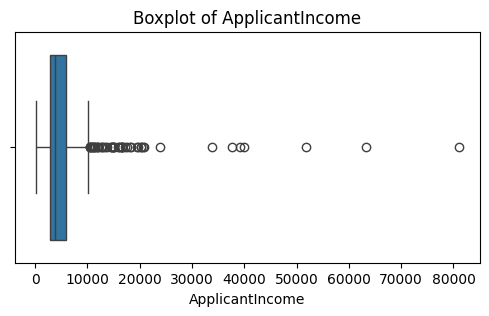

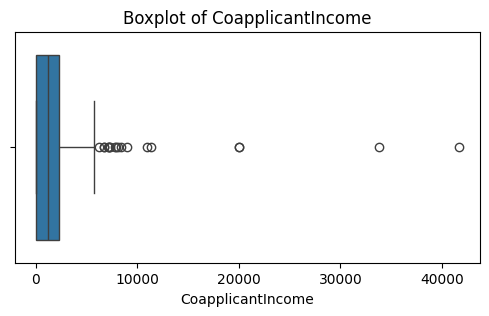

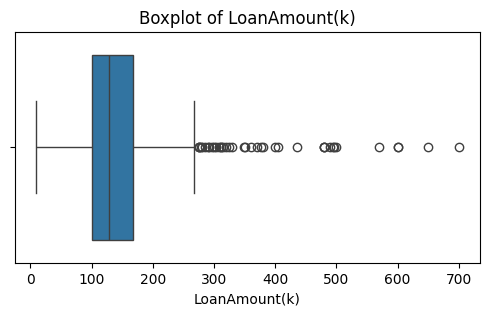

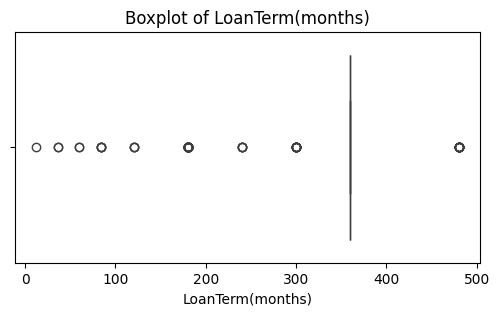

In [19]:
# box plot of the features
cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount(k)','LoanTerm(months)']

for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Column: ApplicantIncome
Skewness: 6.539513113994625


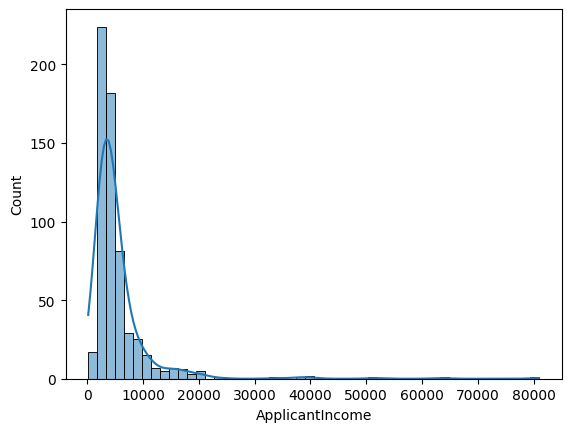

Column: CoapplicantIncome
Skewness: 7.491531216657306


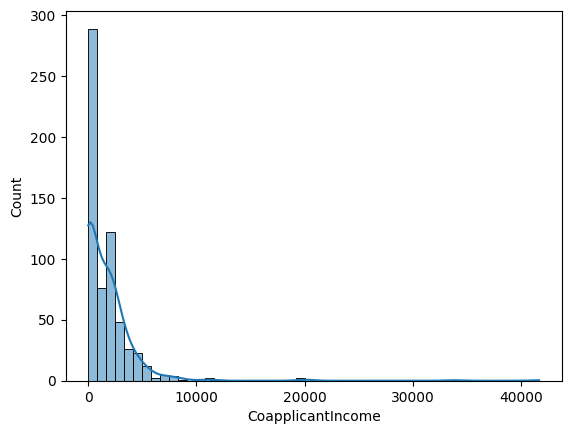

Column: LoanAmount(k)
Skewness: 2.677551679256059


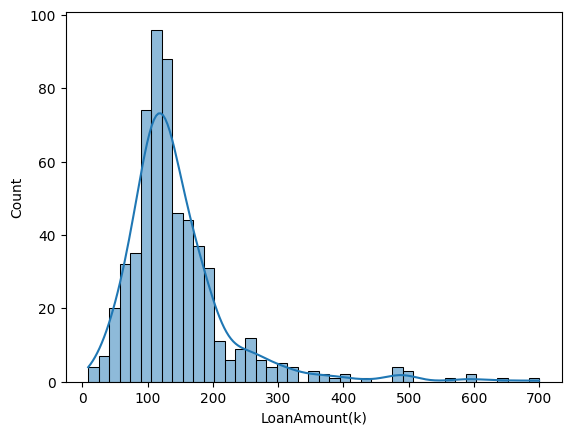

Column: LoanTerm(months)
Skewness: -2.362414124216269


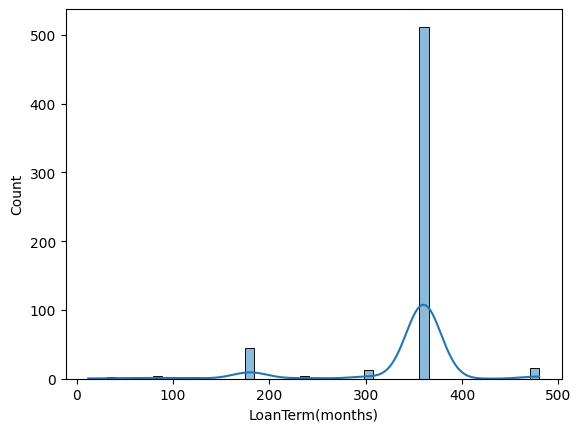

In [20]:
# checking skewness 
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount(k)','LoanTerm(months)']

for col in num_cols:
    
    print("Column:", col)
    print("Skewness:", df[col].skew())
    
    sns.histplot(df[col], kde=True)
    plt.show()

In [21]:
# new feature (Total Income), that can help us in determining whether the loan will be approved or not.
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount(k),LoanTerm(months),Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,9613.0
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y,3849.0
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N,5540.0
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y,5532.0
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N,23809.0


In [22]:
# log transformation to reduce skewness
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])

df['CoapplicantIncome_log'] = np.log1p(df['CoapplicantIncome'])

df['LoanAmount_log'] = np.log1p(df['LoanAmount(k)'])

df['TotalIncome_log'] = np.log1p(df['TotalIncome'])

In [23]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount(k),LoanTerm(months),Credit_History,Property_Area,Loan_Status,TotalIncome,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,TotalIncome_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0,8.674197,0.000000,NaN,8.674197
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,8.430327,7.319202,4.859812,8.714732
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,8.006701,0.000000,4.204693,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,7.857094,7.765993,4.795791,8.505525
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,8.699681,0.000000,4.955827,8.699681
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,9613.0,8.597482,8.342125,5.590987,9.170976
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y,3849.0,7.755339,7.324490,4.564348,8.255828
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N,5540.0,8.018625,7.826044,5.068904,8.619930
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y,5532.0,8.295798,7.331060,5.129899,8.618485
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N,23809.0,9.460476,9.302828,5.857933,10.077861


In [24]:
# new features
df[['ApplicantIncome',
    'ApplicantIncome_log',
    'TotalIncome',
    'TotalIncome_log',
    'LoanAmount(k)',
    'LoanAmount_log']].head()

,ApplicantIncome,ApplicantIncome_log,TotalIncome,TotalIncome_log,LoanAmount(k),LoanAmount_log
0,5849,8.674197,5849.0,8.674197,NaN,NaN
1,4583,8.430327,6091.0,8.714732,128.0,4.859812
2,3000,8.006701,3000.0,8.006701,66.0,4.204693
3,2583,7.857094,4941.0,8.505525,120.0,4.795791
4,6000,8.699681,6000.0,8.699681,141.0,4.955827


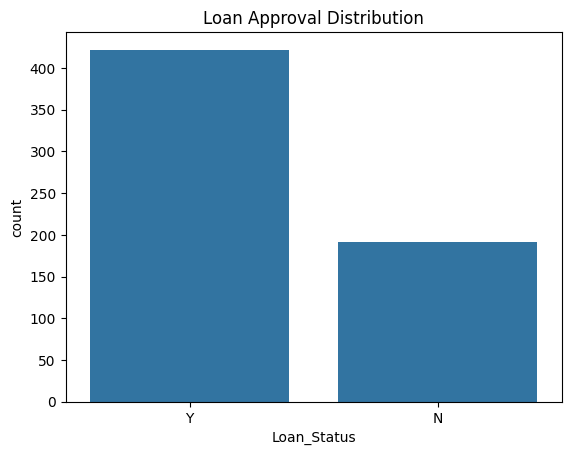

In [25]:
# checking the distribution of the target variable
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

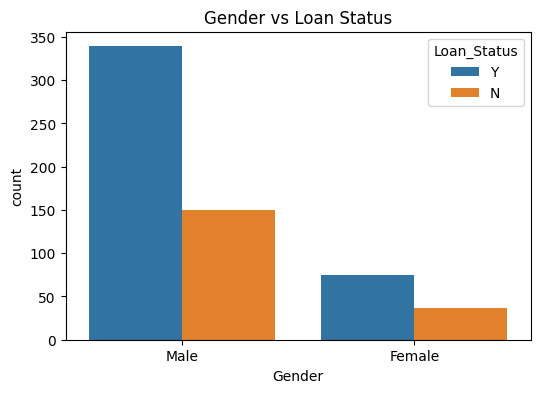

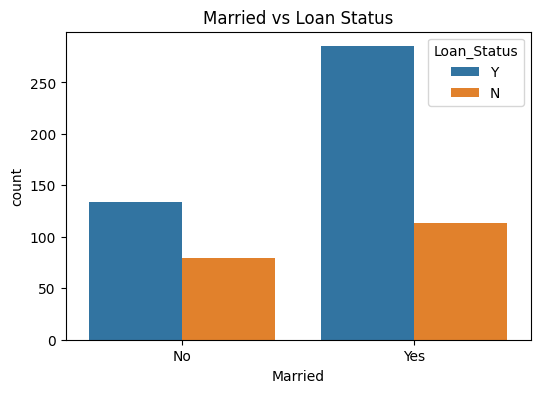

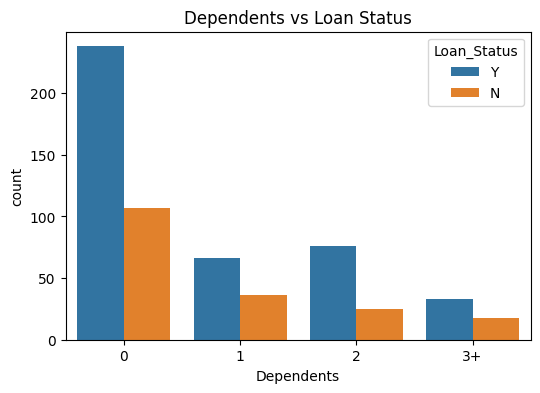

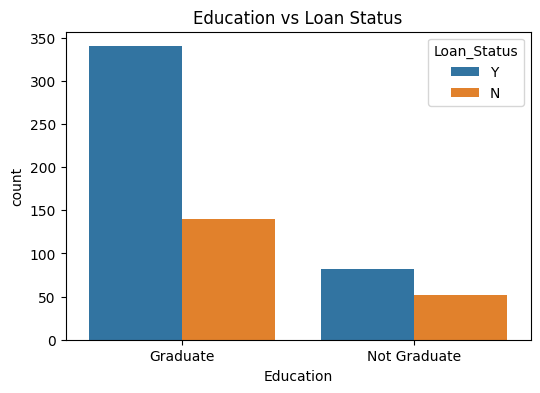

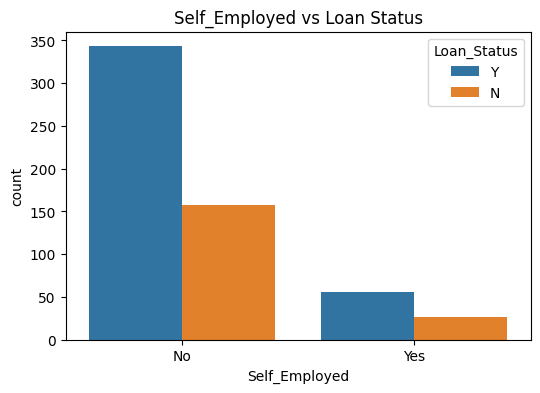

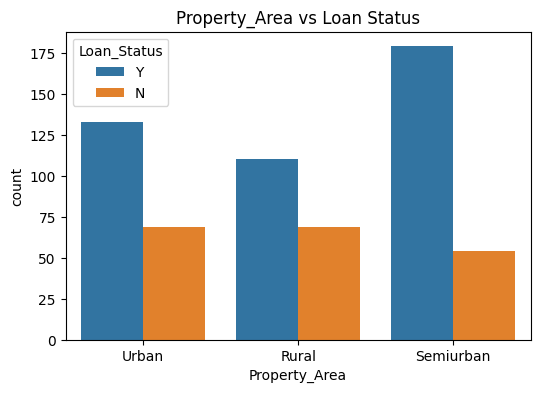

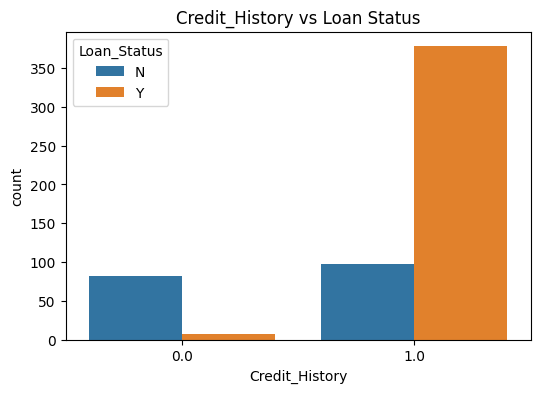

In [26]:
# checking the relationship between categorical features and the target variable
categorical_cols = [
    'Gender','Married','Dependents','Education',
    'Self_Employed','Property_Area','Credit_History'
]

for col in categorical_cols:
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Loan_Status', data=df)
    plt.title(f"{col} vs Loan Status")
    plt.show()

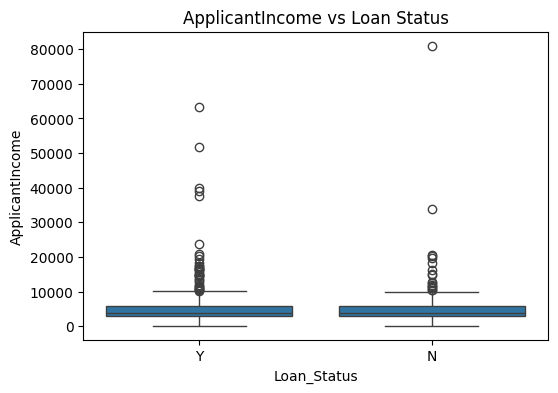

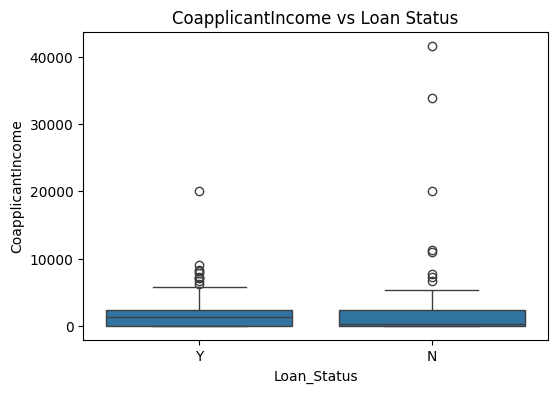

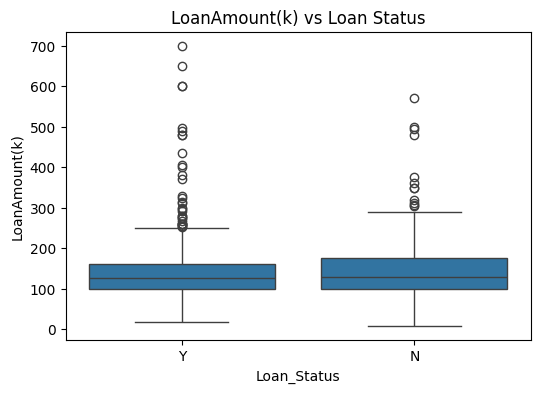

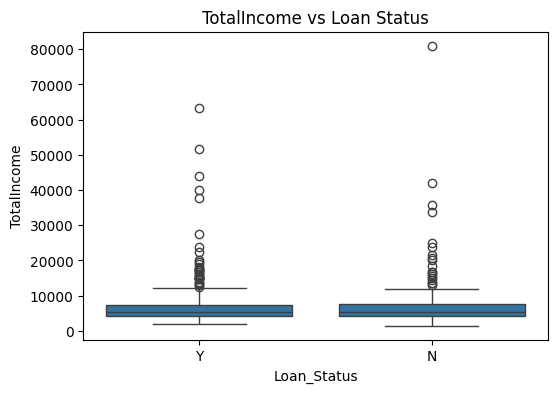

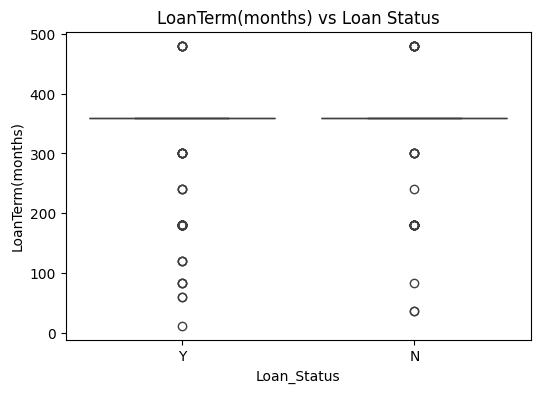

In [27]:
# checking the relationship between numerical features and the target variable
numerical_cols = [
    'ApplicantIncome','CoapplicantIncome',
    'LoanAmount(k)','TotalIncome','LoanTerm(months)'
]

for col in numerical_cols:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Loan_Status', y=col, data=df)
    plt.title(f"{col} vs Loan Status")
    plt.show()

In [28]:
# correlation heatmap to see the relationship between numerical features and the target variable
df['Loan_Status_num'] = df['Loan_Status'].map({'Y':1, 'N':0})

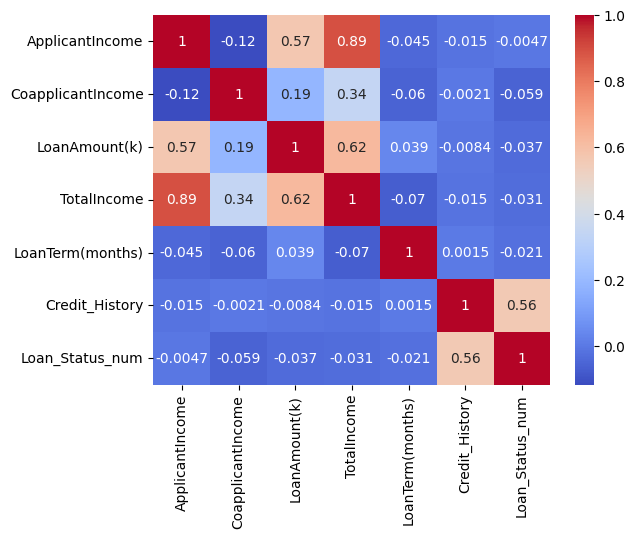

In [29]:
# correlation heatmap to see the relationship between numerical features and the target variable
corr = df[['ApplicantIncome','CoapplicantIncome','LoanAmount(k)',
           'TotalIncome','LoanTerm(months)','Credit_History',
           'Loan_Status_num']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [30]:
# heatmap shows that Credit_History has the highest correlation with Loan_Status,
# followed by TotalIncome and LoanAmount(k). 
# This indicates that these features are likely to be important predictors for loan approval.

In [31]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount(k),LoanTerm(months),Credit_History,Property_Area,Loan_Status,TotalIncome,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,TotalIncome_log,Loan_Status_num
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0,8.674197,0.000000,NaN,8.674197,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,8.430327,7.319202,4.859812,8.714732,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,8.006701,0.000000,4.204693,8.006701,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,7.857094,7.765993,4.795791,8.505525,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,8.699681,0.000000,4.955827,8.699681,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,9613.0,8.597482,8.342125,5.590987,9.170976,1
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y,3849.0,7.755339,7.324490,4.564348,8.255828,1
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N,5540.0,8.018625,7.826044,5.068904,8.619930,0
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y,5532.0,8.295798,7.331060,5.129899,8.618485,1
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N,23809.0,9.460476,9.302828,5.857933,10.077861,0


In [32]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome',
       'LoanAmount(k)', 'LoanTerm(months)', 'Credit_History', 'Property_Area',
       'Loan_Status', 'TotalIncome', 'ApplicantIncome_log',
       'CoapplicantIncome_log', 'LoanAmount_log', 'TotalIncome_log',
       'Loan_Status_num'],
      dtype='str')

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Loan_ID                614 non-null    str    
 1   Gender                 601 non-null    str    
 2   Married                611 non-null    str    
 3   Dependents             599 non-null    str    
 4   Education              614 non-null    str    
 5   Self_Employed          582 non-null    str    
 6   ApplicantIncome        614 non-null    int64  
 7   CoapplicantIncome      614 non-null    float64
 8   LoanAmount(k)          592 non-null    float64
 9   LoanTerm(months)       600 non-null    float64
 10  Credit_History         564 non-null    float64
 11  Property_Area          614 non-null    str    
 12  Loan_Status            614 non-null    str    
 13  TotalIncome            614 non-null    float64
 14  ApplicantIncome_log    614 non-null    float64
 15  CoapplicantIncome

In [34]:
# dropping the Loan_ID column because it is not useful for our analysis and modeling.
df.drop(columns=['Loan_ID'], inplace=True)

In [35]:
# # dropping the original income columns because we have created new features (TotalIncome) 
# # and log transformed features that can be more useful for our analysis and modeling.
# df.drop(columns=[
#     'ApplicantIncome',
#     'CoapplicantIncome',
#     'TotalIncome'
# ], inplace=True)

In [36]:
# # dropping the original LoanAmount column because we have created a log transformed feature (LoanAmount_log)
# df.drop(columns=['LoanAmount(k)'], inplace=True)

In [37]:
# dropping the original LoanTerm column because we have created a numeric feature of the loan status
df.drop(columns=['Loan_Status'], inplace=True)

In [38]:
# # renaming the log transformed features to their original names for better readability and to avoid confusion in the modeling phase.
# df.rename(columns={
#     'ApplicantIncome_log':'ApplicantIncome',
#     'CoapplicantIncome_log':'CoapplicantIncome',
#     'LoanAmount_log':'LoanAmount',
#     'TotalIncome_log':'TotalIncome'
# # }, inplace=True)

In [39]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount(k),LoanTerm(months),Credit_History,Property_Area,TotalIncome,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,TotalIncome_log,Loan_Status_num
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,5849.0,8.674197,0.000000,NaN,8.674197,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,6091.0,8.430327,7.319202,4.859812,8.714732,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,3000.0,8.006701,0.000000,4.204693,8.006701,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,4941.0,7.857094,7.765993,4.795791,8.505525,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,6000.0,8.699681,0.000000,4.955827,8.699681,1
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,9613.0,8.597482,8.342125,5.590987,9.170976,1
6,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,3849.0,7.755339,7.324490,4.564348,8.255828,1
7,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,5540.0,8.018625,7.826044,5.068904,8.619930,0
8,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,5532.0,8.295798,7.331060,5.129899,8.618485,1
9,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,23809.0,9.460476,9.302828,5.857933,10.077861,0


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 601 non-null    str    
 1   Married                611 non-null    str    
 2   Dependents             599 non-null    str    
 3   Education              614 non-null    str    
 4   Self_Employed          582 non-null    str    
 5   ApplicantIncome        614 non-null    int64  
 6   CoapplicantIncome      614 non-null    float64
 7   LoanAmount(k)          592 non-null    float64
 8   LoanTerm(months)       600 non-null    float64
 9   Credit_History         564 non-null    float64
 10  Property_Area          614 non-null    str    
 11  TotalIncome            614 non-null    float64
 12  ApplicantIncome_log    614 non-null    float64
 13  CoapplicantIncome_log  614 non-null    float64
 14  LoanAmount_log         592 non-null    float64
 15  TotalIncome_log  

In [41]:
# separating the features and the target variable for modeling
X = df.drop(columns=['Loan_Status_num'])
y = df['Loan_Status_num']

In [42]:
# categorical columns and numerical columns for preprocessing
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 
                    'Self_Employed', 'Property_Area']

numeric_cols = ['LoanTerm(months)', 'Credit_History', 'ApplicantIncome_log',
                'CoapplicantIncome_log', 'LoanAmount_log', 'TotalIncome_log']

In [43]:
# preprocessing pipelines for numerical and categorical features
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [44]:
# combining the numerical and categorical pipelines into a single column transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [45]:
# splitting the data into training and testing sets with stratification to maintain the same distribution of the target variable in both sets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
# creating a pipeline that combines the preprocessor and a logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [47]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [48]:
# making predictions and evaluating the model
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

In [49]:
# evaluating the model using accuracy, ROC-AUC, classification report, and confusion matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8536585365853658
ROC-AUC: 0.871826625386997

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123


Confusion Matrix:
 [[21 17]
 [ 1 84]]


In [51]:
# Training predictions
y_train_pred = baseline_model.predict(X_train)

# Testing predictions
y_test_pred = baseline_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8004073319755601
Testing Accuracy: 0.8536585365853658


In [52]:
X_train.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount(k),LoanTerm(months),Credit_History,Property_Area,TotalIncome,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,TotalIncome_log
154,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban,3254.0,8.087948,0.000000,3.931826,8.087948
239,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban,3315.0,8.106515,0.000000,4.574711,8.106515
448,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural,5050.0,8.114025,7.444833,5.017280,8.527342
471,Male,Yes,1,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural,4153.0,7.883823,7.313887,4.736198,8.331827
273,Male,Yes,0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban,4843.0,7.871311,7.707063,5.017280,8.485496
71,Male,Yes,2,Not Graduate,Yes,1875,1875.0,97.0,360.0,1.0,Semiurban,3750.0,7.536897,7.536897,4.584967,8.229778
590,Male,Yes,0,Graduate,No,3000,3416.0,56.0,180.0,1.0,Semiurban,6416.0,8.006701,8.136518,4.043051,8.766706
187,Male,Yes,0,Graduate,No,2383,2138.0,58.0,360.0,NaN,Rural,4521.0,7.776535,7.668094,4.077537,8.416710
404,Female,No,0,Graduate,Yes,7441,0.0,194.0,360.0,1.0,Rural,7441.0,8.914895,0.000000,5.273000,8.914895
159,Male,Yes,0,Graduate,No,4583,5625.0,255.0,360.0,1.0,Semiurban,10208.0,8.430327,8.635154,5.545177,9.231025


In [108]:
# for decision tree and random forest models, we will use the original numerical features instead of the log transformed features 
# because these models are not affected by skewness and can handle outliers better than logistic regression.
cat_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area'
]

num_cols = [
    'LoanTerm(months)',
    'Credit_History',
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount(k)',
    'TotalIncome',
]

In [ ]:
# preprocessing pipelines for numerical and categorical features for decision tree and random forest models 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_pipeline_tree, num_cols),
    ('cat', categorical_pipeline_tree, cat_cols)
])

In [105]:
# creating a pipeline that combines the preprocessor and a decision tree model
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', DecisionTreeClassifier(
        criterion='entropy',
        max_depth=3,
        min_samples_split=20,
        min_samples_leaf=8,
        class_weight='balanced',
        random_state=42
    ))
])

In [106]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [107]:
from sklearn.metrics import accuracy_score

y_train_pred_dt = decision_tree_model.predict(X_train)
y_test_pred_dt = decision_tree_model.predict(X_test)

train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)

print("Decision Tree Training Accuracy:", train_acc_dt)
print("Decision Tree Testing Accuracy:", test_acc_dt)

Decision Tree Training Accuracy: 0.8024439918533605
Decision Tree Testing Accuracy: 0.8536585365853658


In [96]:
y_test_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [97]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_dt))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred_dt))

ROC-AUC: 0.7981424148606812

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.61      0.72        38
           1       0.85      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123


Confusion Matrix:
 [[23 15]
 [ 3 82]]


In [109]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_rf = ColumnTransformer(transformers=[
    ('num', numeric_pipeline_rf, num_cols),
    ('cat', categorical_pipeline_rf, cat_cols)
])

In [110]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [111]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [112]:
y_train_pred_rf = random_forest_model.predict(X_train)
y_test_pred_rf = random_forest_model.predict(X_test)
y_test_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [113]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print("Random Forest Training Accuracy:", train_acc_rf)
print("Random Forest Testing Accuracy:", test_acc_rf)
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))

Random Forest Training Accuracy: 0.8778004073319755
Random Forest Testing Accuracy: 0.8292682926829268
ROC-AUC: 0.8365325077399381

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.66      0.70        38
           1       0.86      0.91      0.88        85

    accuracy                           0.83       123
   macro avg       0.81      0.78      0.79       123
weighted avg       0.83      0.83      0.83       123


Confusion Matrix:
 [[25 13]
 [ 8 77]]
